# 01 Train DeepPCB

This notebook orchestrates the non-referential DeepPCB reconstruction from Fung et al. (2024): Faster R-CNN + ResNet-50 + SF-PSPyramid + RoI Align + two fully connected box heads + Soft-NMS + multi-scale training.

Scope intentionally excluded here:
- No SOCT or symbolic classifier
- No referential/template-based detector
- No TDD dataset


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

from neuro.datasets import DeepPCBDataset, summarize_deeppcb_split
from neuro.trainer import run_training
from neuro.transforms import build_eval_transforms
from neuro.utils import load_yaml

PROJECT_ROOT = Path.cwd().resolve()

## Reconstruction Notes And Explicit Assumptions

- The paper specifies the core detector structure, multi-scale sizes, warmup, SGD, random flip, Soft-NMS threshold, and RPN positive/negative IoU rules.
- The paper does not explicitly map numeric DeepPCB labels to class names, so `configs/model.yaml` uses the standard six-class order as an assumption.
- `MConv` and `SF attention` are implemented in a minimal paper-consistent form because the paper omits some low-level details.
- Batch size, exact anchor sizes, and backbone pretraining are explicit config choices rather than hidden defaults.
- Training uses `trainval.txt` only. Final metrics are computed on `test.txt` only after all epochs finish.


In [2]:
model_config = load_yaml(PROJECT_ROOT / "configs/model.yaml")
train_config = load_yaml(PROJECT_ROOT / "configs/train_deeppcb.yaml")
train_config["dataset"]["root"] = str(PROJECT_ROOT / train_config["dataset"]["root"])
train_config["artifacts"]["checkpoint_dir"] = str(
    PROJECT_ROOT / train_config["artifacts"]["checkpoint_dir"]
)
train_config["artifacts"]["feature_export_dir"] = str(
    PROJECT_ROOT / train_config["artifacts"]["feature_export_dir"]
)
class_names = tuple(model_config["model"]["class_names"])

train_summary = summarize_deeppcb_split(
    train_config["dataset"]["root"],
    train_config["dataset"]["train_split"],
    class_names=class_names,
)
test_summary = summarize_deeppcb_split(
    train_config["dataset"]["root"],
    train_config["dataset"]["test_split"],
    class_names=class_names,
)

train_summary, test_summary

({'num_images': 1000,
  'num_boxes': 6873,
  'class_counts': {'open': 1283,
   'short': 1028,
   'mouse_bite': 1379,
   'spur': 1142,
   'pinhole': 1010,
   'spurious_copper': 1031}},
 {'num_images': 500,
  'num_boxes': 3140,
  'class_counts': {'open': 659,
   'short': 478,
   'mouse_bite': 586,
   'spur': 483,
   'pinhole': 464,
   'spurious_copper': 470}})

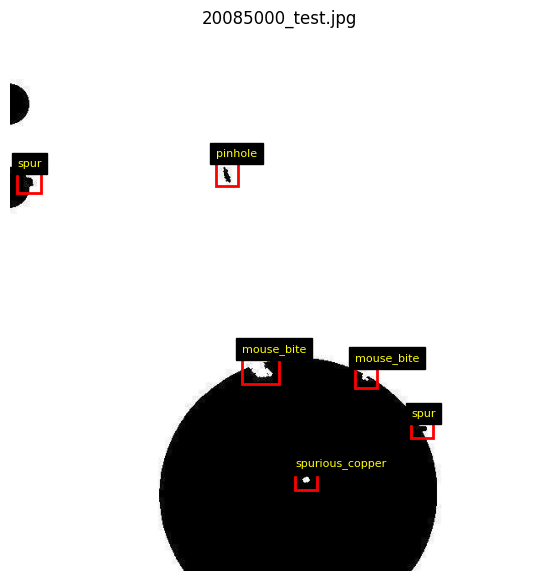

In [3]:
dataset = DeepPCBDataset(
    dataset_root=train_config["dataset"]["root"],
    split_file=train_config["dataset"]["train_split"],
    transforms=build_eval_transforms(),
    class_names=class_names,
)

image, target = dataset[0]
sample = dataset.samples[0]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(image.permute(1, 2, 0), cmap="gray")
for box, label in zip(target["boxes"], target["labels"]):
    x1, y1, x2, y2 = box.tolist()
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="red", facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(
        x1,
        max(y1 - 4, 0),
        class_names[int(label) - 1],
        color="yellow",
        fontsize=8,
        backgroundcolor="black",
    )
ax.set_title(sample.image_path.name)
ax.axis("off")
plt.show()

In [4]:
run_result = run_training(model_config=model_config, train_config=train_config)
run_result["metrics"]

Epoch 1/12 | loss_total=0.8596 | loss_classifier=0.4387 | loss_box_reg=0.2981 | loss_objectness=0.1018 | loss_rpn_box_reg=0.0210


Epoch 2/12 | loss_total=0.6719 | loss_classifier=0.2464 | loss_box_reg=0.3980 | loss_objectness=0.0116 | loss_rpn_box_reg=0.0159


Epoch 3/12 | loss_total=0.5353 | loss_classifier=0.1590 | loss_box_reg=0.3558 | loss_objectness=0.0070 | loss_rpn_box_reg=0.0134


Epoch 4/12 | loss_total=0.4853 | loss_classifier=0.1388 | loss_box_reg=0.3290 | loss_objectness=0.0054 | loss_rpn_box_reg=0.0121


Epoch 5/12 | loss_total=0.4444 | loss_classifier=0.1225 | loss_box_reg=0.3060 | loss_objectness=0.0045 | loss_rpn_box_reg=0.0113


...

Epoch 9/12 | loss_total=0.2831 | loss_classifier=0.0660 | loss_box_reg=0.2077 | loss_objectness=0.0019 | loss_rpn_box_reg=0.0075


Epoch 10/12 | loss_total=0.2677 | loss_classifier=0.0610 | loss_box_reg=0.1977 | loss_objectness=0.0019 | loss_rpn_box_reg=0.0071


Epoch 11/12 | loss_total=0.2625 | loss_classifier=0.0594 | loss_box_reg=0.1944 | loss_objectness=0.0017 | loss_rpn_box_reg=0.0070


Epoch 12/12 | loss_total=0.2540 | loss_classifier=0.0570 | loss_box_reg=0.1886 | loss_objectness=0.0017 | loss_rpn_box_reg=0.0068


{'mAP@0.5:0.95': 0.7609032392501831,
 'mAP@0.5': 0.9801862239837646,
 'AP75': 0.9172776937484741,
 'AP@50:5:85': 0.9025804996490479,
 'precision': 0.9097900029577048,
 'recall': 0.9796178343949045,
 'mar_100': 0.8474597334861755,
 'precision_recall_score_threshold': 0.5,
 'per_class_AP': {'open': 0.6869093179702759,
  'short': 0.6485353708267212,
  'mouse_bite': 0.7540234923362732,
  'spur': 0.7302480936050415,
  'pinhole': 0.8825065493583679,
  'spurious_copper': 0.863196611404419}}

In [5]:
history_frame = pd.DataFrame(run_result["history"])
history_frame

,loss_total,lr,loss_classifier,loss_box_reg,loss_objectness,loss_rpn_box_reg,epoch
0,0.859619,0.014995,0.438708,0.298103,0.101817,0.020992,1.0
1,0.671923,0.020000,0.246446,0.397999,0.011604,0.015873,2.0
2,0.535256,0.020000,0.159014,0.355794,0.007048,0.013400,3.0
3,0.485259,0.020000,0.138769,0.328957,0.005416,0.012116,4.0
4,0.444379,0.020000,0.122488,0.306041,0.004509,0.011342,5.0
5,0.396519,0.020000,0.101002,0.281500,0.003725,0.010292,6.0
6,0.370989,0.020000,0.092546,0.265078,0.003509,0.009855,7.0
7,0.362155,0.020000,0.090931,0.259219,0.002629,0.009375,8.0
8,0.283057,0.002000,0.065990,0.207696,0.001882,0.007489,9.0
9,0.267668,0.002000,0.060953,0.197655,0.001913,0.007147,10.0


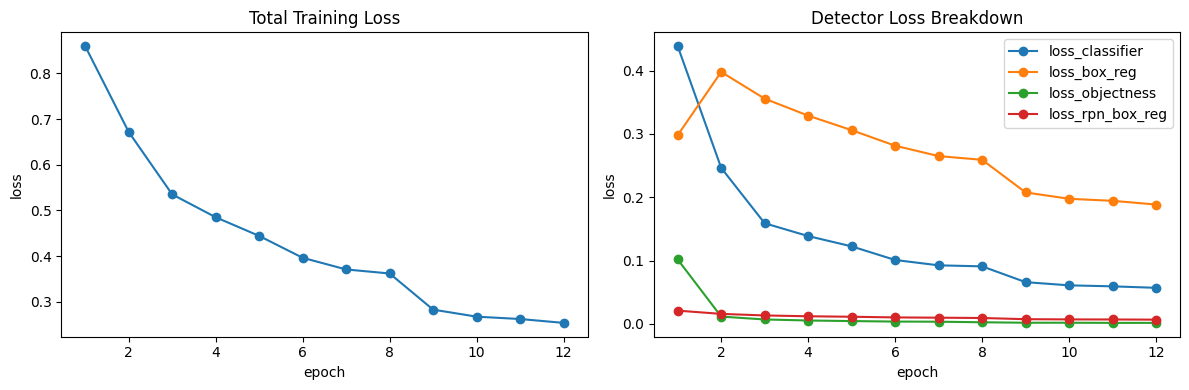

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_frame.plot(x="epoch", y="loss_total", marker="o", ax=axes[0], legend=False)
axes[0].set_title("Total Training Loss")
axes[0].set_ylabel("loss")

history_frame.plot(
    x="epoch",
    y=[
        column
        for column in [
            "loss_classifier",
            "loss_box_reg",
            "loss_objectness",
            "loss_rpn_box_reg",
        ]
        if column in history_frame
    ],
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Detector Loss Breakdown")
axes[1].set_ylabel("loss")
plt.tight_layout()

In [7]:
assert Path(run_result["checkpoint_path"]).exists()
assert Path(run_result["metrics_path"]).exists()
assert Path(run_result["history_path"]).exists()
run_result

{'run_name': 'run3',
 'checkpoint_path': '/home/wiszel/Documents/S1/Semester 8/pcb_skripsi/checkpoints/run3.pt',
 'metrics_path': '/home/wiszel/Documents/S1/Semester 8/pcb_skripsi/checkpoints/run3_metrics.json',
 'history_path': '/home/wiszel/Documents/S1/Semester 8/pcb_skripsi/checkpoints/run3_train_history.json',
 'metrics': {'mAP@0.5:0.95': 0.7609032392501831,
  'mAP@0.5': 0.9801862239837646,
  'AP75': 0.9172776937484741,
  'AP@50:5:85': 0.9025804996490479,
  'precision': 0.9097900029577048,
  'recall': 0.9796178343949045,
  'mar_100': 0.8474597334861755,
  'precision_recall_score_threshold': 0.5,
  'per_class_AP': {'open': 0.6869093179702759,
   'short': 0.6485353708267212,
   'mouse_bite': 0.7540234923362732,
   'spur': 0.7302480936050415,
   'pinhole': 0.8825065493583679,
   'spurious_copper': 0.863196611404419}},
 'history': [{'loss_total': 0.8596194855123759,
   'lr': 0.014995009999999788,
   'loss_classifier': 0.43870771734416486,
   'loss_box_reg': 0.2981026977444999,
   'los